In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from rss import evaluate, features, preprocess, train, utils

print('✓ Core libraries imported')

✓ Core libraries imported


In [2]:
CUSTOM_DIR = Path.cwd() # Update with actual path to project directory
# Data directory structure:
# data/
#       sleep-cassette/
#       sleep-telemetry/
DATA_DIR = CUSTOM_DIR / 'data' # Update with actual path to data
SC_DIR = DATA_DIR / 'sleep-cassette'
ST_DIR = DATA_DIR / 'sleep-telemetry'

# Checkpoint directories (modify as needed)
FEATURE_DIR_SC = CUSTOM_DIR / 'checkpoints/features/RF/sc'
FEATURE_DIR_ST = CUSTOM_DIR / 'checkpoints/features/RF/st'
MODEL_DIR = CUSTOM_DIR / 'checkpoints/model/RF'

for path in [FEATURE_DIR_SC, FEATURE_DIR_ST, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('SC:', SC_DIR)
print('ST:', ST_DIR)
print('Feature checkpoints:', FEATURE_DIR_SC, FEATURE_DIR_ST)
print('Model checkpoint:', MODEL_DIR)

SC: c:\Users\E1024679\Documents\RobustSleepStaging\data\sleep-cassette
ST: c:\Users\E1024679\Documents\RobustSleepStaging\data\sleep-telemetry
Feature checkpoints: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\st
Model checkpoint: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\model\RF


In [3]:
def discover_pairs(root_dir):
    """Return sorted (psg, hypnogram) pairs from a Sleep-EDF cohort directory."""
    psgs = sorted(Path(root_dir).glob('*-PSG.edf'))
    pairs = []
    for psg in psgs:
        subject_id = psg.name[:6]
        hyp_files = list(Path(root_dir).glob(f'{subject_id}*-Hypnogram.edf'))
        if hyp_files:
            pairs.append((psg, hyp_files[0]))
    return pairs


sc_pairs = discover_pairs(SC_DIR)
st_pairs = discover_pairs(ST_DIR)
print(f'SC pairs found: {len(sc_pairs)}')
print(f'ST pairs found: {len(st_pairs)}')

example_psg, example_hyp = sc_pairs[0]
raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
annotations = mne.read_annotations(example_hyp)
raw.set_annotations(annotations)

print(f'Example recording: {example_psg.name}')
print(f'Channels in file: {raw.ch_names}')
print(f'Sampling frequency: {raw.info["sfreq"]} Hz')
print(f'Duration: {raw.times[-1] / 3600:.2f} h')
print(f'Annotations: {len(annotations)} segments')

SC pairs found: 153
ST pairs found: 44


C:\Users\E1024679\AppData\Local\Temp\ipykernel_6600\3121516847.py:19: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_6600\3121516847.py:19: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_6600\3121516847.py:19: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)


Example recording: SC4001E0-PSG.edf
Channels in file: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Sampling frequency: 100.0 Hz
Duration: 22.08 h
Annotations: 154 segments


C:\Users\E1024679\AppData\Local\Temp\ipykernel_6600\3121516847.py:21: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


[preprocess] loading PSG: SC4011E0-PSG.edf, hypnogram: SC4011EH-Hypnogram.edf


c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:47: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


[preprocess] channels picked: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental'], sampling freq: 100.0 Hz
[preprocess] first sleep onset: 21540.0 seconds
[preprocess] cropped recording from: 19740.0 seconds
[preprocess] kept 30 min of wake before sleep
[preprocess] extracted epochs: 2144 epochs, shape per epoch: (4, 3000) 
[features] computing PSD for 2144 epochs (sfreq=100.0)
[features] PSD computed — elapsed: 3.8s, psd shape: (2144, 4, 1186)
Feature matrix shape: (2144, 4744)


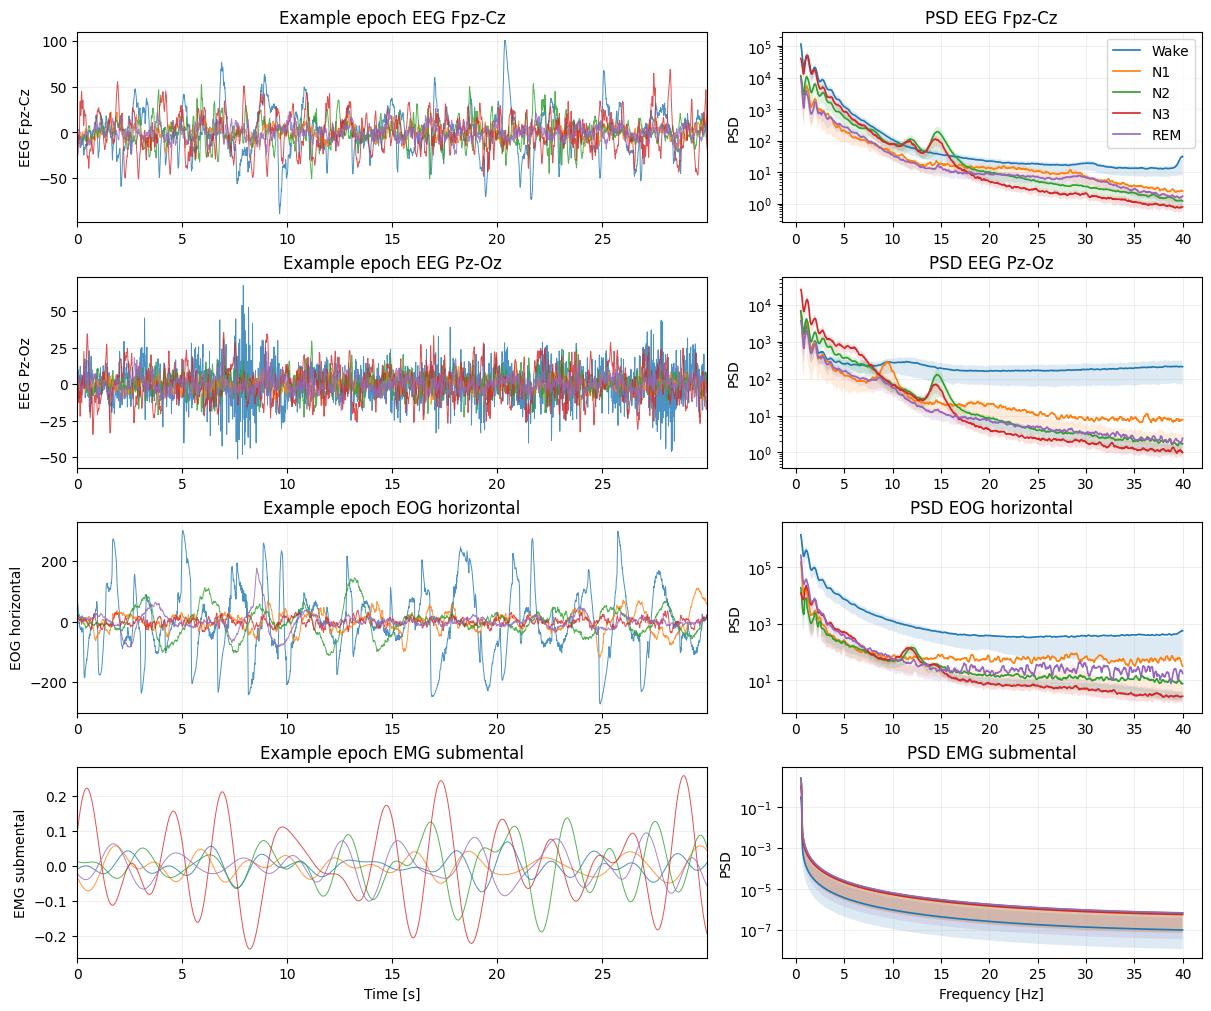

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

X_epochs, y_labels, sfreq = preprocess.load_subject_epochs(sc_pairs[2][0], sc_pairs[2][1], preprocess.COMMON_CHANNELS, verbose=True)
X_features, freqs = features.extract_psd_features(X_epochs, sfreq, verbose=True)
print(f'Feature matrix shape: {X_features.shape}')

# Raw snippet
start_sec = 0
end_sec = 30
start_sample = int(start_sec * raw.info["sfreq"])
end_sample = int(end_sec * raw.info["sfreq"])

times = np.arange(start_sample, end_sample) / raw.info["sfreq"]
#data, _ = raw[:len(preprocess.COMMON_CHANNELS), start_sample:end_sample]

# PSD reshape
channel_names = preprocess.COMMON_CHANNELS
n_channels = len(channel_names)
n_freqs = len(freqs)
X_psd = X_features.reshape(len(y_labels), n_channels, n_freqs)
X_epochs = X_epochs.reshape(len(y_labels), n_channels, -1)[:, :, start_sample:end_sample]

fig = plt.figure(figsize=(12, 2.5 * n_channels), constrained_layout=True)
gs = GridSpec(
    n_channels,
    2,
    figure=fig,
    width_ratios=[1.5, 1],
)

for ch_i, channel in enumerate(channel_names):
    # Left: raw trace
    ax_raw = fig.add_subplot(gs[ch_i, 0])

    # Right: PSD by stage
    ax_psd = fig.add_subplot(gs[ch_i, 1])

    for label in np.unique(y_labels):
        mask = y_labels == label
        random_trace = X_epochs[mask, ch_i, :][0]  # Take the first trace for this stage
        psd_label = X_psd[mask, ch_i, :]

        mean = psd_label.mean(axis=0)
        lo = np.percentile(psd_label, 25, axis=0)
        hi = np.percentile(psd_label, 75, axis=0)

        stage_name = preprocess.STAGE_NAMES.get(int(label), f"label {label}")

        ax_psd.plot(freqs, mean, lw=1.2, label=stage_name)
        ax_psd.fill_between(freqs, lo, hi, alpha=0.15)
        ax_psd.set_title(f"PSD {channel}")

        ax_raw.plot(times, random_trace, lw=0.7, alpha=0.8, label=stage_name)
        ax_raw.set_title(f"Example epoch {channel}")

    ax_psd.set_yscale("log")
    ax_psd.grid(alpha=0.2)
    ax_raw.set_ylabel(channel)
    ax_raw.grid(alpha=0.2)
    ax_raw.margins(x=0)

    if ch_i == 0:
        # ax_psd.set_title("Average PSD with IQR by stage")
        ax_psd.legend()
    if ch_i == n_channels - 1:
        ax_psd.set_xlabel("Frequency [Hz]")
        ax_raw.set_xlabel("Time [s]")

    ax_psd.set_ylabel("PSD")

plt.show()

In [31]:
# Build / load feature arrays from the checkpoint folders
model_path_1 = MODEL_DIR / 'random_forest_no_scaling.pkl'
model_path_2 = MODEL_DIR / 'random_forest_sc_reduced.pkl'

# Load SC features and labels for training and validation
X_sc, y_sc, sid_sc = utils.load_per_record_checkpoints(FEATURE_DIR_SC, load_mode='disk')
print('SC features:', X_sc.shape)

if X_sc.size > 0:
    unique_subjects = np.unique(sid_sc)
    print(unique_subjects)
    train_subjects, val_subjects = train_test_split(unique_subjects, test_size=0.2, random_state=42)
    print('Train subjects:', train_subjects)
    print('Validation subjects:', val_subjects)
    train_mask = np.isin(sid_sc, train_subjects)
    val_mask = np.isin(sid_sc, val_subjects)

    X_train_raw = X_sc[train_mask]
    y_train = y_sc[train_mask]
    X_val_raw = X_sc[val_mask]
    y_val = y_sc[val_mask]

    if model_path_1.exists():
        clf_1 = joblib.load(model_path_1)
        clf_2 = joblib.load(model_path_2)

        print('Loaded existing model checkpoints:')
        print('  no scaling:', model_path_1)
        
    else:
        pass

else:
    print('No SC checkpoints found yet; run the preprocessing cell first.')

[utils] load_mode=disk — scanning checkpoint directory: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc
[utils] found 153 .npz files
[utils] scanned 50/153 files — total_epochs so far: 96419
[utils] scanned 100/153 files — total_epochs so far: 190942
[utils] scanned 150/153 files — total_epochs so far: 291065
SC features: (296936, 4744)
['SC400' 'SC401' 'SC402' 'SC403' 'SC404' 'SC405' 'SC406' 'SC407' 'SC408'
 'SC409' 'SC410' 'SC411' 'SC412' 'SC413' 'SC414' 'SC415' 'SC416' 'SC417'
 'SC418' 'SC419' 'SC420' 'SC421' 'SC422' 'SC423' 'SC424' 'SC425' 'SC426'
 'SC427' 'SC428' 'SC429' 'SC430' 'SC431' 'SC432' 'SC433' 'SC434' 'SC435'
 'SC436' 'SC437' 'SC438' 'SC440' 'SC441' 'SC442' 'SC443' 'SC444' 'SC445'
 'SC446' 'SC447' 'SC448' 'SC449' 'SC450' 'SC451' 'SC452' 'SC453' 'SC454'
 'SC455' 'SC456' 'SC457' 'SC458' 'SC459' 'SC460' 'SC461' 'SC462' 'SC463'
 'SC464' 'SC465' 'SC466' 'SC467' 'SC470' 'SC471' 'SC472' 'SC473' 'SC474'
 'SC475' 'SC476' 'SC477' 'SC480' 'SC481' 'SC482']
T

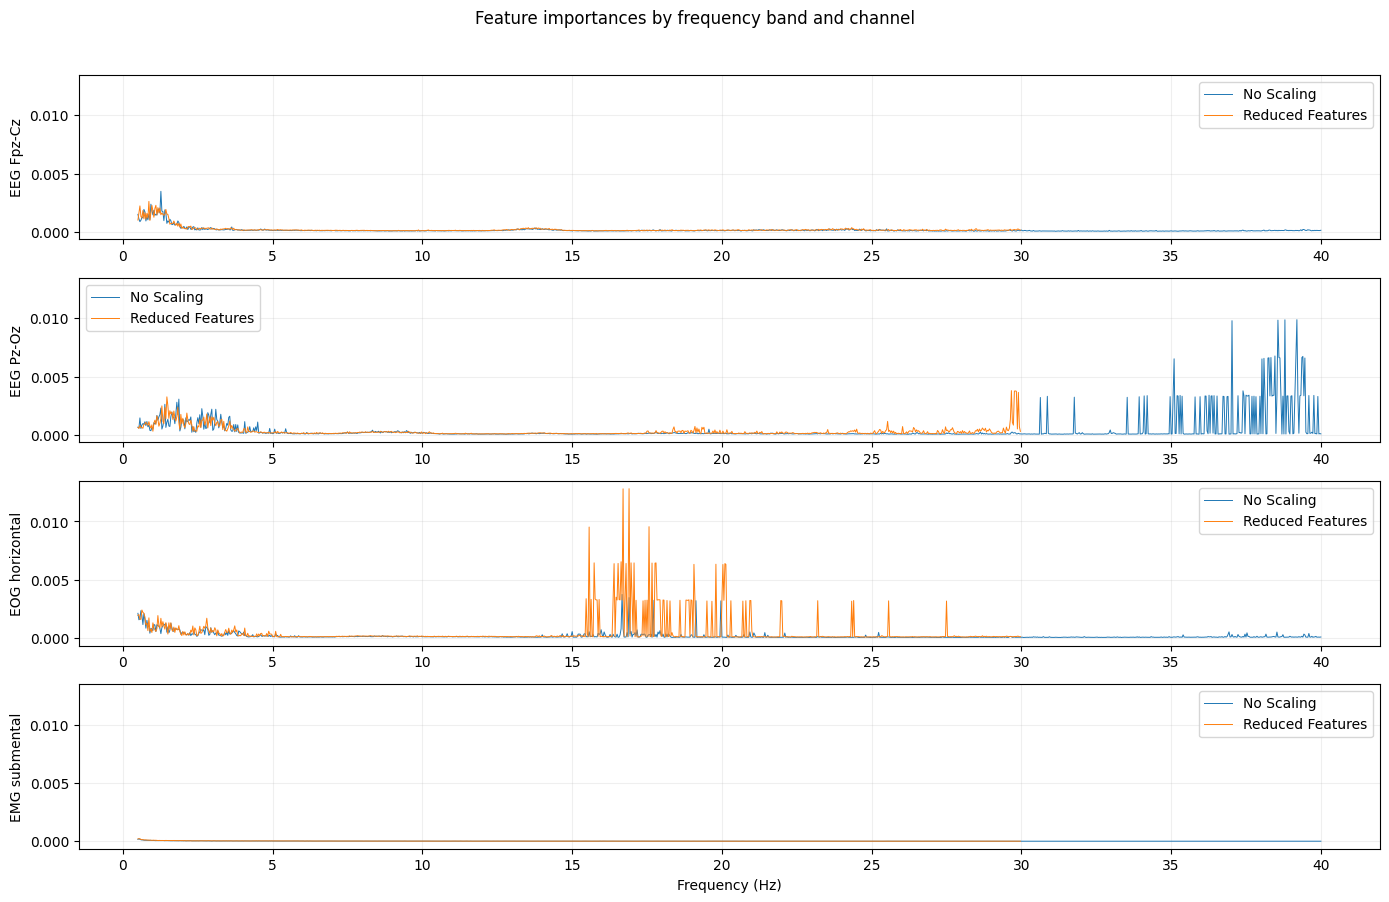

In [32]:
freqs_1 = freqs.copy()
freqs_2 = freqs.copy()[:885]

fig, axes = plt.subplots(len(preprocess.COMMON_CHANNELS), 1, figsize=(14, 2.2 * len(preprocess.COMMON_CHANNELS)), sharey=True)
for i_channel, channel in enumerate(preprocess.COMMON_CHANNELS):
    ax = axes[i_channel]
    feature_importances_1 = clf_1.feature_importances_[i_channel * len(freqs_1):(i_channel + 1) * len(freqs_1)]
    feature_importances_2 = clf_2.feature_importances_[i_channel * len(freqs_2):(i_channel + 1) * len(freqs_2)]
    ax.plot(freqs_1, feature_importances_1, lw=0.7, label='No Scaling')
    ax.plot(freqs_2, feature_importances_2, lw=0.7, label='Reduced Features')
    ax.set_ylabel(channel)
    ax.grid(alpha=0.2)
    ax.legend()
axes[-1].set_xlabel('Frequency (Hz)')
fig.suptitle('Feature importances by frequency band and channel', y=1.02)
plt.tight_layout()
plt.show()

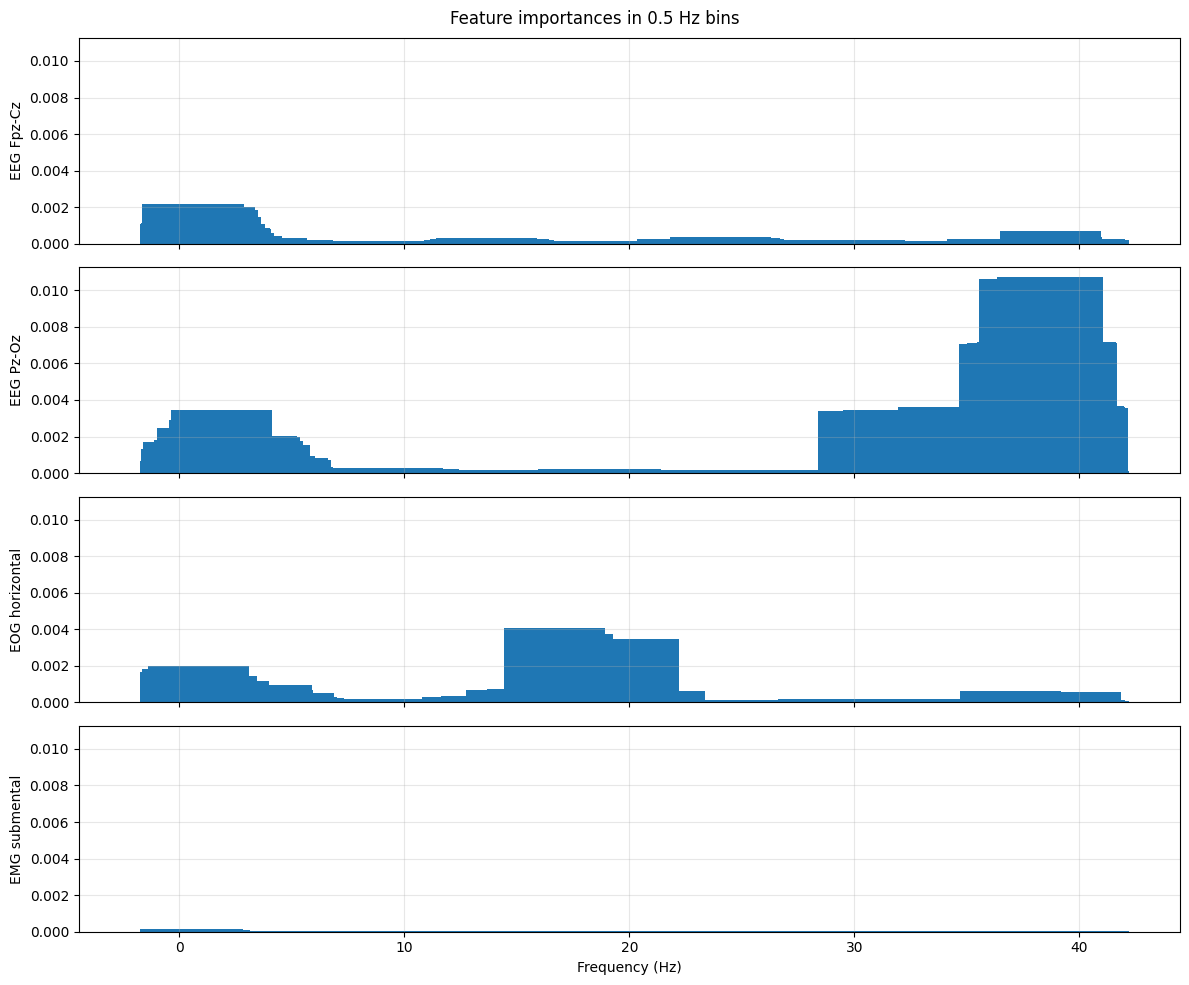

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

imp = clf.feature_importances_.reshape(len(preprocess.COMMON_CHANNELS), len(freqs))

bin_width = 0.01
bins = np.arange(0, 40 + bin_width, bin_width)
centers = (bins[:-1] + bins[1:]) / 2

binned = np.zeros((len(preprocess.COMMON_CHANNELS), len(centers)))

for i in range(len(centers)):
    mask = (freqs >= bins[i]) & (freqs < bins[i + 1])
    binned[:, i] = imp[:, mask].sum(axis=1)

fig, axes = plt.subplots(len(preprocess.COMMON_CHANNELS), 1, figsize=(12, 2.5 * len(preprocess.COMMON_CHANNELS)), sharex=True, sharey=True)

for ch_i, ax in enumerate(np.ravel(axes)):
    ax.bar(centers, binned[ch_i], width=4.5)
    ax.set_ylabel(preprocess.COMMON_CHANNELS[ch_i])
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Frequency (Hz)")
fig.suptitle("Feature importances in 0.5 Hz bins")
plt.tight_layout()
plt.show()